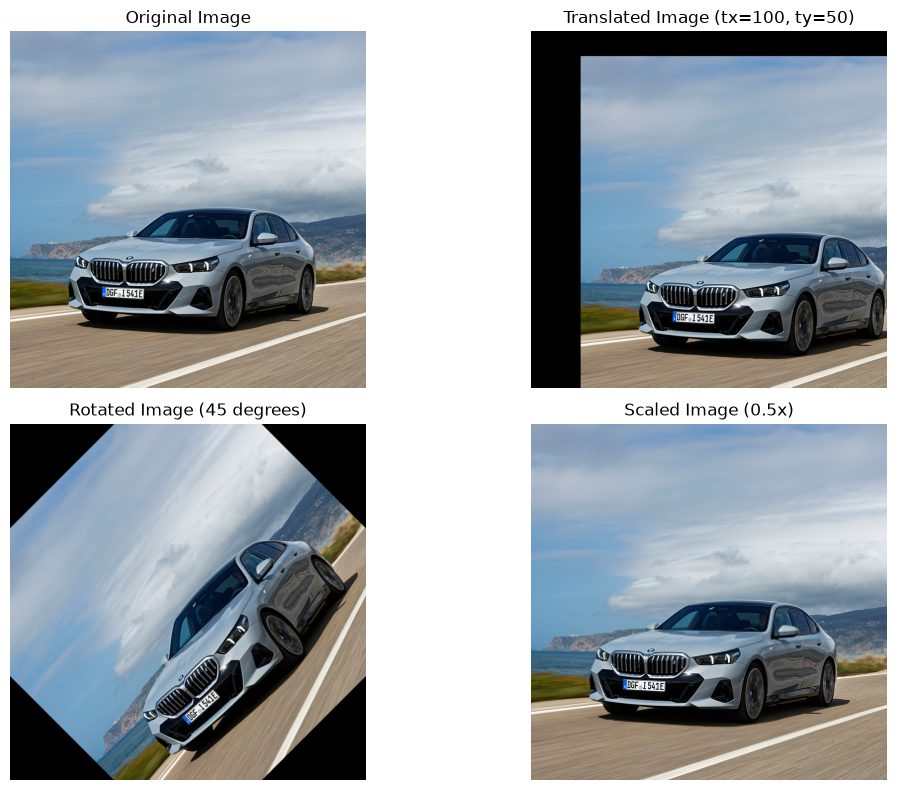

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('BMW.jpeg')
# Convert BGR to RGB for Matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get image dimensions
rows, cols = image_rgb.shape[:2]

# 1. Translation
# Shift 100 pixels right and 50 pixels down
tx, ty = 100, 50
translation_matrix = np.float32([[1, 0, tx], [0, 1, ty]])
translated_img = cv2.warpAffine(image_rgb, translation_matrix, (cols, rows))

# 2. Rotation
# Rotate by 45 degrees around the center
center = (cols / 2, rows / 2)
angle = 45
# 1.0 is the scale factor (keeping it original size during rotation)
rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
rotated_img = cv2.warpAffine(image_rgb, rotation_matrix, (cols, rows))

# 3. Scaling
# Scale down by 0.5x in both directions
sx, sy = 0.5, 0.5
scaled_img = cv2.resize(image_rgb, None, fx=sx, fy=sy, interpolation=cv2.INTER_LINEAR)

# Plotting the results
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(translated_img)
plt.title('Translated Image (tx=100, ty=50)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(rotated_img)
plt.title('Rotated Image (45 degrees)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(scaled_img)
plt.title('Scaled Image (0.5x)')
plt.axis('off')

plt.tight_layout()
plt.show()